<a href="https://colab.research.google.com/github/oliviapang/DS_3001_Assignments/blob/main/Assignment_3/3_Linear_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Question 1

In [2]:
'''
1. A model is 'linear' because it assumes a linear relationship between the input and target/output variables. Each term is
weighted by a coefficient, creating the equation for a line. Additionally, if a function is multiplied by a scalar and returns
a linear funciton, it is linear.
2. The coefficient for a dummy variable represents how much the target variable changes for each unit of the input, as compared
to the dropped/reference column. The intercept of the model represents the value of the dropped column.
3. Technically, linear regression can be used for classification if you use it to calculate probabilities and set a threshold for
classification (e.g. > 0.5 is 1 and < 0.5 is 0). However, linear regression can return values less than 0 and greater than 1, which
can't really be interpreted as probabilities.
4. One sign a model is overfitting is if it performs well on training data but poorly on the test set. This indicates that it is
"seeing" patterns in the training data that aren't there. Another sign is higher variance in predictions. Models that are too
complex tend to have high variance and overfit the data.
5. The first stage of the two-stage least squares technique involves running a regression between y and an independent variable
(xk) on all other independent variables. Residuals are calculated for y and xk. Then, a single linear regression is run on those
residuals. Multi-colinearity occurs when two independent variables explain the same changes in target variable. The coefficients found
for those variables in the first stage regression will not reflect the predictor's singular effect on the target variable;
instead, they will represent the variables partial effect, greatly impacted by which other variable are present in the model. The
highly correlated variables will effectively cancel each other out, producing a hightly variable model.
6. Nonlinear relationships between the target and independent variables can be introduced via latent variable models. A latent
variable (say, x1*b) is passed into a nonlinear activation function, and a prediction value is obtained. Depending on the desired
outcome, different activation functions can be used.
7. The slope coefficient represents how much the target value will change for each unit input value.
8. Train/test split divides the data once, and trains the model only on that one set of training data. In k-fold cross validation,
the data is split into k folds/chunks and, trained on k-1 chunks, and tested on the kth chunk. This process repeats k times.
9. There is not a set way to select k, and its value depends on bias or variance you want the model to have. A low k-value will
be faster to compute but may be more biased because it had fewer training sets. A higher k-value will provide bias but may have
more variance if the model is overfitting the data. Additionally, if the data set is small, a higher k value may be necessary to ensure
there is enough training data.
'''

'\n1. A model is \'linear\' because it assumes a linear relationship between the input and target/output variables. Each term is \nweighted by a coefficient, creating the equation for a line. Additionally, if a function is multiplied by a scalar and returns\na linear funciton, it is linear. \n2. The coefficient for a dummy variable represents how much the target variable changes for each unit of the input, as compared\nto the dropped/reference column. The intercept of the model represents the value of the dropped column. \n3. Technically, linear regression can be used for classification if you use it to calculate probabilities and set a threshold for\nclassification (e.g. > 0.5 is 1 and < 0.5 is 0). However, linear regression can return values less than 0 and greater than 1, which\ncan\'t really be interpreted as probabilities.\n4. One sign a model is overfitting is if it performs well on training data but poorly on the test set. This indicates that it is\n"seeing" patterns in the trai

Question 2

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
# 1
! git clone https://github.com/oliviapang/DS_3001_Assignments

fatal: destination path 'DS_3001_Assignments' already exists and is not an empty directory.


In [5]:
df = pd.read_csv('/content/DS_3001_Assignments/Assignment_3/Q1_clean.csv')
df.head()

,Price,Review Scores Rating,Neighbourhood,Property Type,Room Type
0,549,96.0,Manhattan,Apartment,Private room
1,149,100.0,Brooklyn,Apartment,Entire home/apt
2,250,100.0,Manhattan,Apartment,Entire home/apt
3,90,94.0,Brooklyn,Apartment,Private room
4,270,90.0,Manhattan,Apartment,Entire home/apt


In [6]:
df.columns

Index(['Price', 'Review Scores Rating', 'Neighbourhood ', 'Property Type',
       'Room Type'],
      dtype='object')

In [7]:
print(df.groupby('Neighbourhood ')['Price'].mean())
print(df.groupby('Neighbourhood ')['Review Scores Rating'].mean())

Neighbourhood 
Bronx             75.276498
Brooklyn         127.747378
Manhattan        183.664286
Queens            96.857233
Staten Island    146.166667
Name: Price, dtype: float64
Neighbourhood 
Bronx            91.654378
Brooklyn         92.363497
Manhattan        91.801496
Queens           91.549057
Staten Island    90.843750
Name: Review Scores Rating, dtype: float64


In [8]:
'''
On average, Manhattan is the most expensive.
'''

'\nOn average, Manhattan is the most expensive.\n'

<Axes: xlabel='Price', ylabel='Density'>

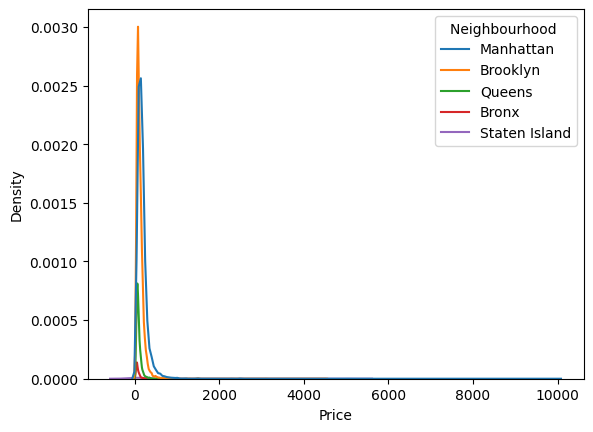

In [9]:
# price
sns.kdeplot(data = df, x = df['Price'], hue = 'Neighbourhood ')

<Axes: xlabel='Price', ylabel='Density'>

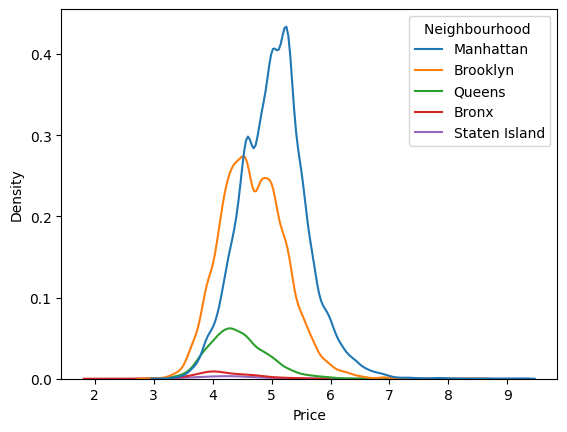

In [10]:
# log price
sns.kdeplot(data = df, x = np.log(df['Price']), hue = 'Neighbourhood ')

In [11]:
# 2
from sklearn.linear_model import LinearRegression

X = pd.get_dummies(df['Neighbourhood '], drop_first = True) # independent
y = df['Price'] # target
model = LinearRegression()
model = model.fit(X, y)
print(f'Model intercept: {model.intercept_}')
pd.DataFrame({'variable':model.feature_names_in_, 'coefficient':model.coef_ })

Model intercept: 75.27649769585331


,variable,coefficient
0,Brooklyn,52.470881
1,Manhattan,108.387789
2,Queens,21.580735
3,Staten Island,70.890169


In [12]:
'''
The coefficients here represent the change in price for each neighbourhood as compared to the mean price for the Bronx (the
dropped category). For example, a location in Brooklyn will add $52.47 to the mean Bronx price, making the price total $127.75
The conditional group means equal the Bronx mean plus their corresponding estimated coefficient.
'''

'\nThe coefficients here represent the change in price for each neighbourhood as compared to the mean price for the Bronx (the\ndropped category). For example, a location in Brooklyn will add $52.47 to the mean Bronx price, making the price total $127.75\nThe conditional group means equal the Bronx mean plus their corresponding estimated coefficient.\n'

In [13]:
# 3
X = df[['Review Scores Rating']]
y = df['Price']
model = LinearRegression()
model.fit(X, y)

print(f'Model intercept: {model.intercept_}')
print(f"Slope (Review Scores Rating): {model.coef_[0]}")
#pd.DataFrame({'variable':model.feature_names_in_, 'coefficient':model.coef_ })

Model intercept: 60.878390657123546
Slope (Review Scores Rating): 1.0208266022674763


In [14]:
'''
The slope coefficient represents how much the price will change if the review score increases by one unit (1 point). Here, the
price will go up by about $1.02 for each one point increase in the review score.
'''

'\nThe slope coefficient represents how much the price will change if the review score increases by one unit (1 point). Here, the\nprice will go up by about $1.02 for each one point increase in the review score. \n'

In [15]:
# 4
X_neighbourhood = pd.get_dummies(df['Neighbourhood '], drop_first = True)
X_review = df.loc[:, 'Review Scores Rating']
X = pd.concat([X_neighbourhood, X_review], axis = 1)
y = df['Price']
model = LinearRegression()
model = model.fit(X, y)

print(f'Model intercept: {model.intercept_}')
pd.DataFrame({'variable':model.feature_names_in_, 'coefficient':model.coef_ })

Model intercept: -23.812561011672244


,variable,coefficient
0,Brooklyn,51.704240
1,Manhattan,108.228737
2,Queens,21.694600
3,Staten Island,71.766552
4,Review Scores Rating,1.081116


In [23]:
'''
The slope on "Review Scores Rating" increased slightly. The "Neighbourhood" averages increased slightly for Brooklyn and Manhattan
and decreased slightly for Queens and Staten Island.
'''

'\nThe slope on "Review Scores Rating" increased slightly. The "Neighbourhood" averages increased slightly for Brooklyn and Manhattan\nand decreased slightly for Queens and Staten Island. \n'

In [24]:
# 5
neighbourhoods = pd.get_dummies(df['Neighbourhood '], dtype = 'int')
neighbourhoods
X = neighbourhoods.mul(df['Review Scores Rating'], axis = 0) # multiply dummy dataframe by Review Score; 1 means listing is in that neighbourhood, score is kept instead of going to 0
y = df['Price']
model = LinearRegression()
model = model.fit(X, y)
pd.DataFrame({'variable':model.feature_names_in_, 'coefficient':model.coef_ })


,variable,coefficient
0,Bronx,0.222718
1,Brooklyn,0.790947
2,Manhattan,1.399376
3,Queens,0.456451
4,Staten Island,0.682444


In [ ]:
'''
The slopes are not similar across neighbourhoods
'''

In [36]:
# 6
# The question says to compare models from parts 4, 5, and 6, but this is part 6 so I am going to assume that I am just comparing models from 4 and 5

from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error

X4 = pd.concat([X_neighbourhood, X_review], axis = 1)
X5 = neighbourhoods.mul(df['Review Scores Rating'], axis = 0)
y = df['Price']
model = LinearRegression()

kfold = KFold(n_splits=10, shuffle=True, random_state=100) # Create folds

scores = cross_val_score(model, X4, y, cv=kfold)

# for model in part 4
print("Fold scores:", scores)
print("Mean score:", np.mean(scores))
print("Median score:", np.median(scores))
print("Std dev:", np.std(scores))
print('\n')

# for model in part 5
scores = cross_val_score(model, X5, y, cv=kfold)
print("Fold scores:", scores)
print("Mean score:", np.mean(scores))
print("Median score:", np.median(scores))
print("Std dev:", np.std(scores))

Fold scores: [0.09129197 0.04804618 0.04145308 0.0454993  0.07111015 0.06252147
 0.01151599 0.08332217 0.08813223 0.07406023]
Mean score: 0.06169527728489137
Median score: 0.06681580948318505
Std dev: 0.02379312679572927


Fold scores: [0.09250633 0.04641651 0.04027593 0.04640433 0.07328355 0.06377529
 0.01364124 0.08615456 0.08913965 0.07527323]
Mean score: 0.06268706173143847
Median score: 0.06852942031125586
Std dev: 0.024184999714956894
